In [2]:
print("Hello, World!") #test python

Hello, World!


# **Task 1**
## **Chris' Code Begins**

In [3]:
import pandas as pd

df = pd.read_csv("support2.csv") # read the dataset into a pandas DataFrame

# Keep an untouched copy of the original dataset, so that we can refer back to it if needed
df_original = df.copy(deep=True)

In [4]:
print("=== Dataset Shape ===")
print(df.shape)

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Data Type Counts ===")
print(df.dtypes.value_counts())

# this section of code cycles through each column and prints the column name, data type, and number of occurrences (non-null values) in that column.

=== Dataset Shape ===
(9105, 47)

=== First 5 Rows ===
        age  death     sex  hospdead  slos  d.time            dzgroup  \
1  62.84998      0    male         0     5    2029        Lung Cancer   
2  60.33899      1  female         1     4       4          Cirrhosis   
3  52.74698      1  female         0    17      47          Cirrhosis   
4  42.38498      1  female         0     3     133        Lung Cancer   
5  79.88495      0  female         0    16    2029  ARF/MOSF w/Sepsis   

              dzclass  num.co   edu  ...      crea    sod        ph  glucose  \
1              Cancer       0  11.0  ...  1.199951  141.0  7.459961      NaN   
2  COPD/CHF/Cirrhosis       2  12.0  ...  5.500000  132.0  7.250000      NaN   
3  COPD/CHF/Cirrhosis       2  12.0  ...  2.000000  134.0  7.459961      NaN   
4              Cancer       2  11.0  ...  0.799927  139.0       NaN      NaN   
5            ARF/MOSF       1   NaN  ...  0.799927  143.0  7.509766      NaN   

   bun  urine adlp  adls 

In [5]:
for col_name in df.columns:
    print(f"Column: {col_name}")
    print(f"Data Type: {df[col_name].dtype}")
    print(f"Occurrences: {df[col_name].count()}")
    print("-" * 40) 
    # cycles through each column and prints the column name, data type, and number of occurrences (non-null values) in that column.
    # exact same as the block above but makes visual id faster and more precise, not that i did anything with it. 

Column: age
Data Type: float64
Occurrences: 9105
----------------------------------------
Column: death
Data Type: int64
Occurrences: 9105
----------------------------------------
Column: sex
Data Type: str
Occurrences: 9105
----------------------------------------
Column: hospdead
Data Type: int64
Occurrences: 9105
----------------------------------------
Column: slos
Data Type: int64
Occurrences: 9105
----------------------------------------
Column: d.time
Data Type: int64
Occurrences: 9105
----------------------------------------
Column: dzgroup
Data Type: str
Occurrences: 9105
----------------------------------------
Column: dzclass
Data Type: str
Occurrences: 9105
----------------------------------------
Column: num.co
Data Type: int64
Occurrences: 9105
----------------------------------------
Column: edu
Data Type: float64
Occurrences: 7471
----------------------------------------
Column: income
Data Type: str
Occurrences: 6123
----------------------------------------
Column: sco

In [6]:
# next is to test the numerical values. 
numeric_cols = df.select_dtypes(include="number").columns

print("=== Numerical Ranges ===")
print(df[numeric_cols].agg(["min", "max"]).T)

# Filter numerical columns with values <= 0 and include the data entry values

=== Numerical Ranges ===
                  min           max
age         18.041990  1.018480e+02
death        0.000000  1.000000e+00
hospdead     0.000000  1.000000e+00
slos         3.000000  3.430000e+02
d.time       3.000000  2.029000e+03
num.co       0.000000  9.000000e+00
edu          0.000000  3.100000e+01
scoma        0.000000  1.000000e+02
charges   1169.000000  1.435423e+06
totcst       0.000000  6.332120e+05
totmcst   -102.719970  7.106820e+05
avtisst      1.000000  8.300000e+01
sps          0.199982  9.918750e+01
aps          0.000000  1.430000e+02
surv2m       0.000000  9.699707e-01
surv6m       0.000000  9.479980e-01
hday         1.000000  1.480000e+02
diabetes     0.000000  1.000000e+00
dementia     0.000000  1.000000e+00
prg2m        0.000000  1.000000e+00
prg6m        0.000000  1.000000e+00
dnrday     -88.000000  2.850000e+02
meanbp       0.000000  1.950000e+02
wblc         0.000000  2.000000e+02
hrt          0.000000  3.000000e+02
resp         0.000000  9.000000e+01
tem

In [7]:
# Select only columns with string (object) dtype
categorical_columns = df.select_dtypes(include='object')

for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))

# this performs a unique value check for each categorical column, which is useful for identifying potential data entry errors or inconsistencies in categorical data.
# everything looks good. 
# this shows us which features are common and which are not, which is useful for understanding the distribution of categorical variables in the dataset. 
# for example we can identify that there are more male patients than female patients, which may be important for understanding the demographics of the dataset and potential biases in the data.


=== sex ===
sex
male      5125
female    3980
Name: count, dtype: int64

=== dzgroup ===
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64

=== dzclass ===
dzclass
ARF/MOSF              4227
COPD/CHF/Cirrhosis    2862
Cancer                1420
Coma                   596
Name: count, dtype: int64

=== income ===
income
NaN           2982
under $11k    2855
$11-$25k      1527
$25-$50k      1057
>$50k          684
Name: count, dtype: int64

=== race ===
race
white       7191
black       1391
hispanic     290
other        112
asian         79
NaN           42
Name: count, dtype: int64

=== ca ===
ca
no            5995
metastatic    1858
yes           1252
Name: count, dtype: int64

=== dnr ===
dnr
no dnr             5880
dnr after sadm     2956
dnr before sadm     239
NaN                  30
Name: c

C:\Users\bally\AppData\Local\Temp\ipykernel_5880\2481327478.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object')


In [8]:
# numerical summary statistics. 
print("=== Numerical Summary Statistics ===")
print(df[numeric_cols].describe().T)
# each feature becomes a row and its helpful for task 3 onwards. 


=== Numerical Summary Statistics ===
           count          mean            std          min          25%  \
age       9105.0     62.650823      15.593710    18.041990    52.797000   
death     9105.0      0.681054       0.466094     0.000000     0.000000   
hospdead  9105.0      0.259198       0.438219     0.000000     0.000000   
slos      9105.0     17.863042      22.006440     3.000000     6.000000   
d.time    9105.0    478.449863     560.383272     3.000000    26.000000   
num.co    9105.0      1.868644       1.344409     0.000000     1.000000   
edu       7471.0     11.747691       3.447743     0.000000    10.000000   
scoma     9104.0     12.058546      24.636694     0.000000     0.000000   
charges   8933.0  59995.787811  102648.778198  1169.000000  9740.000000   
totcst    8217.0  30825.867768   45780.820986     0.000000  5929.566400   
totmcst   5630.0  28828.877838   43604.261932  -102.719970  5177.404300   
avtisst   9023.0     22.610928      13.233248     1.000000    1

# **TASK 2**

In [9]:
print("--- Missing values ---")
print(df.isna().sum())  # Count of missing values per column

print("--- Duplicate rows ---")
print(df.duplicated().sum())  # Count of duplicate rows

print("--- Unique values in 'dzgroup' ---")
print(df["dzgroup"].unique())  # Unique values in the 'dzgroup' column

print("--- Counts of 'race' ---")
print(df["race"].value_counts())  # Count of rows per 'race'

print("--- Summary statistics: continuous variables ---")
continuous_cols = ["age", "slos", "aps", "sps", "meanbp", "wblc", "hrt", "resp", "temp", "pafi", "alb", "bili", "crea", "sod", "ph", "glucose", "bun", "urine"]
print(df[continuous_cols].describe())  # Summary statistics for continuous variables

print("--- Counts of 'year' (if applicable) ---")
if "year" in df.columns:
    print(df["year"].value_counts().sort_index())  # Count of rows per year, if the column exists

print("--- Summary statistics: categorical variables ---")
print(df.describe(include="object"))  # Summary statistics for categorical variables

--- Missing values ---
age            0
death          0
sex            0
hospdead       0
slos           0
d.time         0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv2m         1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
prg2m       1649
prg6m       1633
dnr           30
dnrday        30
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
sfdm2       1400
adlsc          0
dtype: int64
--- Duplicate rows ---
0
--- Unique values in 'dzgroup' ---
<StringArray>
[      'Lung Cancer',         'Cirrhosis', 'ARF/MOSF w/Sepsis',
              'Coma',      

C:\Users\bally\AppData\Local\Temp\ipykernel_5880\3608224190.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))  # Summary statistics for categorical variables


In [10]:
#assumption 1: sensitive data witheld by patients. 
# Filter records with only 'race', 'income', or 'edu' missing
filtered_missing = df[
    (df['race'].isna() & df[['income', 'edu']].notna().all(axis=1)) |
    (df['income'].isna() & df[['race', 'edu']].notna().all(axis=1)) |
    (df['edu'].isna() & df[['race', 'income']].notna().all(axis=1))
]

# Number of records with only 'race', 'income', or 'edu' missing
num_records = filtered_missing.shape[0]
print(f"Number of records with only 'race', 'income', or 'edu' missing: {num_records}")

# Compare 'race', 'income', and 'edu' before and after filtering
race_before = df['race'].isna().sum()
race_after = filtered_missing['race'].isna().sum()

income_before = df['income'].isna().sum()
income_after = filtered_missing['income'].isna().sum()

edu_before = df['edu'].isna().sum()
edu_after = filtered_missing['edu'].isna().sum()

print(f"race_before: {race_before}, race_after: {race_after}")
print(f"income_before: {income_before}, income_after: {income_after}")
print(f"edu_before: {edu_before}, edu_after: {edu_after}")

# practices very basically the assumption i made for sensitive information.

Number of records with only 'race', 'income', or 'edu' missing: 1928
race_before: 42, race_after: 1
income_before: 2982, income_after: 1635
edu_before: 1634, edu_after: 292


In [11]:
# assumption 2, how many records have missing medical values/measurements but also never made it to the surv6m or are dead. 
# Identify health-related features
health_features = ['meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine']

# Check for patients flagged as dead and with more than 2 missing health features
dead_with_missing_health = df[(df['death'] == 1) & (df[health_features].isna().sum(axis=1) > 2)]

# Number of such records
num_dead_with_missing_health = dead_with_missing_health.shape[0]
print(f"Number of patients flagged as dead and with >2 missing health features: {num_dead_with_missing_health}")

# Display the records if needed
print(dead_with_missing_health)

Number of patients flagged as dead and with >2 missing health features: 3777
           age  death     sex  hospdead  slos  d.time            dzgroup  \
2     60.33899      1  female         1     4       4          Cirrhosis   
3     52.74698      1  female         0    17      47          Cirrhosis   
4     42.38498      1  female         0     3     133        Lung Cancer   
6     93.01599      1    male         1     4       4               Coma   
7     62.37097      1    male         0     9     659                CHF   
...        ...    ...     ...       ...   ...     ...                ...   
9024  48.89798      1  female         1     7       7               Coma   
9042  63.59799      1  female         0     5       7  ARF/MOSF w/Sepsis   
9050  61.09497      1    male         0    13      52       Colon Cancer   
9084  85.66498      1  female         1     4       4               Coma   
9085  65.06195      1  female         0    16     376  ARF/MOSF w/Sepsis   

          

In [12]:
dnrday_negative_count = df[df['dnrday'] < 0].shape[0]
print(f"Number of 'dnrday' values less than 0: {dnrday_negative_count}")
# number of records with dnrday < 0 is 195, which is a small percentage of the total dataset.

Number of 'dnrday' values less than 0: 195


In [13]:
print("=== Data Types ===")
print(df.dtypes)

for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))

=== Data Types ===
age         float64
death         int64
sex             str
hospdead      int64
slos          int64
d.time        int64
dzgroup         str
dzclass         str
num.co        int64
edu         float64
income          str
scoma       float64
charges     float64
totcst      float64
totmcst     float64
avtisst     float64
race            str
sps         float64
aps         float64
surv2m      float64
surv6m      float64
hday          int64
diabetes      int64
dementia      int64
ca              str
prg2m       float64
prg6m       float64
dnr             str
dnrday      float64
meanbp      float64
wblc        float64
hrt         float64
resp        float64
temp        float64
pafi        float64
alb         float64
bili        float64
crea        float64
sod         float64
ph          float64
glucose     float64
bun         float64
urine       float64
adlp        float64
adls        float64
sfdm2           str
adlsc       float64
dtype: object

=== sex ===
sex
male      

In [14]:
# next is to test the numerical values. 
numeric_cols = df.select_dtypes(include="number").columns

print("=== Numerical Ranges ===")
print(df[numeric_cols].agg(["min", "max"]).T)

# Filter numerical columns with values <= 0 and include the data entry values

=== Numerical Ranges ===
                  min           max
age         18.041990  1.018480e+02
death        0.000000  1.000000e+00
hospdead     0.000000  1.000000e+00
slos         3.000000  3.430000e+02
d.time       3.000000  2.029000e+03
num.co       0.000000  9.000000e+00
edu          0.000000  3.100000e+01
scoma        0.000000  1.000000e+02
charges   1169.000000  1.435423e+06
totcst       0.000000  6.332120e+05
totmcst   -102.719970  7.106820e+05
avtisst      1.000000  8.300000e+01
sps          0.199982  9.918750e+01
aps          0.000000  1.430000e+02
surv2m       0.000000  9.699707e-01
surv6m       0.000000  9.479980e-01
hday         1.000000  1.480000e+02
diabetes     0.000000  1.000000e+00
dementia     0.000000  1.000000e+00
prg2m        0.000000  1.000000e+00
prg6m        0.000000  1.000000e+00
dnrday     -88.000000  2.850000e+02
meanbp       0.000000  1.950000e+02
wblc         0.000000  2.000000e+02
hrt          0.000000  3.000000e+02
resp         0.000000  9.000000e+01
tem

In [15]:
# Filter numerical columns with values <= 0 and include the data entry values
numerical_columns_with_le_zero = df[numeric_cols].apply(lambda x: x[x < 0])

# Print the columns with <= 0 entries and their values
print("Numerical columns with <= 0 entries and their values:")
for col in numerical_columns_with_le_zero.columns:
    if not numerical_columns_with_le_zero[col].dropna().empty:
        print(f"\nColumn: {col}")
        print(numerical_columns_with_le_zero[col].dropna())
        # the two features with <0 was dnrday and totmcst which are furhter investigated. 

Numerical columns with <= 0 entries and their values:

Column: totmcst
7763   -102.71997
7783    -28.48000
Name: totmcst, dtype: float64

Column: dnrday
27     -1.0
426    -5.0
465    -1.0
486    -9.0
491    -1.0
       ... 
8979   -1.0
8985   -8.0
8993   -1.0
8996   -1.0
9040   -1.0
Name: dnrday, Length: 195, dtype: float64


## **Chris' code ends**
## **Jono's code begins**

In [16]:
#Starting with age, we can remove all outside of reasonable limits
# Filter out records with age < 1 or age > 110

df_clean = df.copy(deep=True)
df_clean = df[(df['age'] >= 0) & (df['age'] <= 110)]

# Number of records removed
removed_records = df.shape[0] - df_clean.shape[0]
print(f"Number of records removed due to invalid age: {removed_records}")

# Display the shape of the filtered dataset
print(f"Filtered dataset shape: {df_clean.shape}")

Number of records removed due to invalid age: 0
Filtered dataset shape: (9105, 47)


In [17]:
# Whether they died is irrelevant to this study

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['death', 'hospdead'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 2


In [18]:
# 'slos' denotes number of days they were in hospital before being discharged.
# A longer stay might imply they are more sickly and have worse odds once discharged.
# All the information seems clean so no work to do here

In [19]:
# 'd.time' denotes number of days patients were in the study. 
# If they didn't reach 2 months they didn't get an sfdm2 value.
# If they exceeded it then they got one and the variable is no longer relevant.
# We can remove the feature

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['d.time'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 1


In [20]:
# 'dzgroup' and 'dzclass' and 'num.co' denote disease types and numbers which will be very helpful.
# Nothing looks out of place based on data scoping in task 1.

In [21]:
# Many education level entries are missing. There is also an individual income column.
# We assumption that education level will not directly affect deterioration in terminally ill patients
# The whole column will simply be removed as its both difficult to average and of low importance.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['edu'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 1


mean      0.929773
median    1.000000
std       1.039705
min       0.000000
max       3.000000
Name: income_bracket_num, dtype: float64

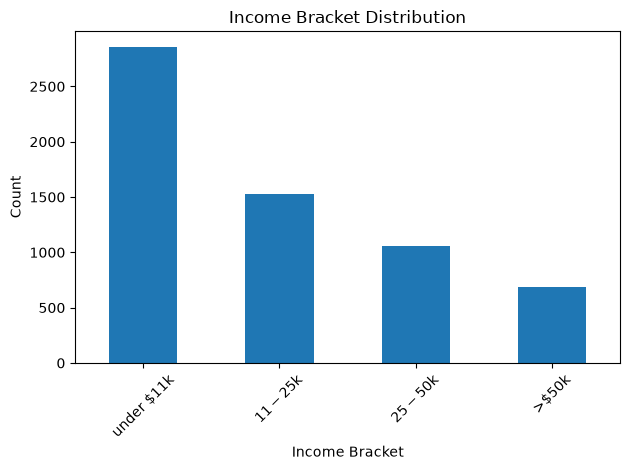

In [22]:
# Income may be a significant factor as this survey is taken in a country without free healthcare.
# Almost 33% of the data for this feature is missing so we will see if taking an average is reasonable.

# Map income bracket strings to integer values
income_mapping = {
    'under $11k': 0,
    '$11-$25k': 1,
    '$25-$50k': 2,
    '>$50k': 3
}

df_clean['income_bracket_num'] = df['income'].map(income_mapping)

print(df_clean['income_bracket_num'].agg(['mean', 'median', 'std', 'min', 'max']))

import matplotlib.pyplot as plt

# Bar chart of value counts for each income bracket
df_clean['income'].value_counts().reindex(
    ['under $11k', '$11-$25k', '$25-$50k', '>$50k']
).plot(kind='bar')

plt.title('Income Bracket Distribution')
plt.xlabel('Income Bracket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# This is very skewed, but making nearly 3000 records move is going to make it much worse.
# Spreading the remainder in accordance with these averages would dilute any potential relationship.
# While this data would be nice, it will have to be removed. 

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['income', 'income_bracket_num'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 2


In [24]:
# 'scoma' is a measure of how deep in a coma they are on a scale of 0 - 100.
# Based on scoping from task 1, all values are in valid ranges but one entry is missing.

before = df_clean.shape[0]
df_clean = df_clean[df_clean['scoma'].notna()]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 1
Remaining rows: 9104


In [25]:
# 'charges' denotes their number of hospital charges.
# This could be useful but there are multiple missing entries

before = df_clean.shape[0]
df_clean = df_clean[df_clean['charges'].notna()]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 171
Remaining rows: 8933


In [26]:
# 'totcst', 'totmcst' and 'avtisst' are all cost related. 
# As this is an american study, we will assume all patients have health insurance and are recieving equal amounts of care.
# These features will be removed.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['totcst', 'totmcst', 'avtisst'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 3


In [27]:
# 'race' denotes as implied.
# Useful information, only a few entires missing, and looks clean based on TS1 scope.
# Will remove empty entries.

before = df_clean.shape[0]
df_clean = df_clean[df_clean['race'].notna()]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 42
Remaining rows: 8891


In [28]:
# 'sps' and 'aps' are both physological scores taken at day 3 that may be very useful
# 'sps' ranges from 0 to 163 and 'aps' ranges from 0 to 299, meaning all recorded values are within spec according to scoping in task 1.
# A few records are missing

before = df_clean.shape[0]
df_clean = df_clean[df_clean['sps'].notna()]
df_clean = df_clean[df_clean['aps'].notna()]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

#These entries must have already been removed in a previous removal.

Rows removed: 0
Remaining rows: 8891


In [29]:
# 'surv2m' and 'surv6m' is a machine's estimate of the patients odds of survival in 2 and 6 months time.
# This wont actually impact what condition they're in in 2 months so we will remove it entirely.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['surv2m', 'surv6m'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 2


In [30]:
# 'hday' denotes the number of days the patient had already been in hospital before being diagnosed as terminally ill.
# This is useful as it tells us how long we have known them to be in this state.
# No entries missing and seems fine based on T1 scope.

# 'diabetes' and 'dementia' are as named and have binary values.
# Useful information
# No entries missing and seems fine based on T1 scope.

# 'ca' denotes cancer and has three potential values.
# Useful information
# No entries missing and seems fine based on T1 scope.

In [31]:
# As per 'surv2m' and 'surv6m', 'prg2m' and 'prg6m' are practitioners guesses at the well being of the patient in 2 and 6 months time.
# Will not effect actual outcome so will be removed.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['prg2m', 'prg6m'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 2


In [32]:
# 'dnr' denotes 'Do not rescusitate' order in three kinds. 
# May be useful in seeing if certain mentalities result in better conditions at two month checkup. 
# All 'dnr' values are valid but some are missing. 

before = df_clean.shape[0]
df_clean = df_clean[df_clean['dnr'].notna()]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

# 'dnrday' marks day of decease and is not useful information.
# Will remove the 'dnrday' feature.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['dnrday'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Rows removed: 4
Remaining rows: 8887
Columns removed: 1


In [33]:
# 'meanbp' is a blood pressure reading on day three. 
# Useful information but 1 record missing, and the minimum is recorded as 0, which is impossible.
# The maximum is very extreme, but these are terminally ill patients. 
# Extremely high and low blood pressures should not be instantly be deemed errors in this instance.

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['meanbp'] != 0) & (df_clean['meanbp'].notna())]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 47
Remaining rows: 8840


In [34]:
# 'wblc' is a white blood cell count measured in thousands on day 3.     
# Useful information but multiple records missing and more absurd values.
# There are records of very high white blood cell counts, but depending on the disease that might make sense.

# Cross-check the extreme wblc rows against heart rate and temperature to see if its abnormal
print(df_clean[df_clean['wblc'] > 100][['wblc', 'dzgroup', 'hrt', 'temp']])

# Compare against the overall averages for context
print("\nOverall average hrt:", df['hrt'].mean())
print("Overall average temp:", df['temp'].mean())

           wblc            dzgroup    hrt      temp
1332  112.18750  ARF/MOSF w/Sepsis  135.0  38.29688
1382  110.00000          Cirrhosis   55.0  38.69531
2910  117.00000  ARF/MOSF w/Sepsis  118.0  38.19531
5408  128.78125                CHF  150.0  38.69531
7527  200.00000  ARF/MOSF w/Sepsis  156.0  39.09375
7565  104.00000               COPD  176.0  39.29688

Overall average hrt: 97.15671114268454
Overall average temp: 37.10334106326889


In [35]:
# All of these entries now seem to fit the bill for high white blood cell count.
# All NaN and 0 results will be removed.

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['wblc'] != 0) & (df_clean['wblc'].notna())]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 218
Remaining rows: 8622


In [36]:
# 'hrt' refers to heart rate measured on day 3.
# Useful information but has readings from 0 to 300. Anything below 30 is practically implausible, so will be considered invalid.
# Will remove the NaN and <20 rows along with the 300 row before rechecking boundires.

before = df_clean.shape[0]

df_clean = df_clean[(df_clean['hrt'] >= 30) & (df_clean['hrt'].notna())]

# Remove the isolated 300 outlier
df_clean = df_clean[df_clean['hrt'] != 300]

after = df_clean.shape[0]
print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

# Recheck min and max
print("New min hrt:", df_clean['hrt'].min())
print("New max hrt:", df_clean['hrt'].max())

Rows removed: 48
Remaining rows: 8574
New min hrt: 30.0
New max hrt: 250.0


In [37]:
# Inspect patients with hrt between 150 and 250, alongside other relevant clinical context to see if they make any sense
print(
    df_clean[(df_clean['hrt'] >= 150) & (df_clean['hrt'] <= 250)]
    [['hrt', 'dzgroup', 'temp', 'meanbp', 'resp', 'wblc']]
    .sort_values('hrt', ascending=False)
)

# Realising I'm not a Doctor and have no idea what I'm meant to be looking for 

        hrt            dzgroup      temp  meanbp  resp       wblc
8542  250.0  ARF/MOSF w/Sepsis  35.79688    55.0  24.0  14.298828
7687  232.0        Lung Cancer  39.09375    52.0  43.0   7.799805
6527  232.0  ARF/MOSF w/Sepsis  36.00000    29.0  46.0   9.099609
5512  225.0                CHF  36.69531    48.0  26.0  20.296875
4463  224.0  ARF/MOSF w/Sepsis  37.89844   134.0   8.0  17.699219
...     ...                ...       ...     ...   ...        ...
346   150.0  ARF/MOSF w/Sepsis  36.79688    52.0  35.0   6.500000
683   150.0       MOSF w/Malig  36.29688    60.0  40.0   0.049995
8409  150.0  ARF/MOSF w/Sepsis  39.00000   132.0   8.0   8.199219
8423  150.0               Coma  38.19531   123.0  36.0  17.898438
8722  150.0               COPD  38.79688    60.0  42.0   3.699707

[418 rows x 6 columns]


In [38]:
# 'resp' is the resperation rate of the patient measured on day 3. 
# Useful information but one record marked as missing and more entries at 0.
# I don't know why they keep monitoring people in the morgue.
# I don't want those entries.
# Those aren't useful entires.
# Any reocrds at a rate below 4 will be removed because that's someone on the way to the morgue.
# 90 seems plausible so will be left as is. 

before = df_clean.shape[0]

df_clean = df_clean[df_clean['resp'] != 0]
df_clean = df_clean[df_clean['resp'] >= 4]

after = df_clean.shape[0]
print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

print("New min resp:", df_clean['resp'].min())
print("New max resp:", df_clean['resp'].max())

Rows removed: 18
Remaining rows: 8556
New min resp: 4.0
New max resp: 90.0


In [39]:
# 'temp' refers to body tempreture.
# Useful information that seems to land within bounds but is marked as missing one entry.

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['temp'].notna())]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

# Must have been previously removed.

Rows removed: 0
Remaining rows: 8556


In [40]:
# 'pafi', 'alb' and 'bili' are all simply missing to many rows to be used to have averages applied.
# 'pafi' is an oxygen metric. Useful to keep where possible.
# 'alb' is serum albumin levels. Useful to keep where possible.
# 'bili' is bilirubin levels. Useful to keep where possible.

before = df.shape[0]
df_pab = df_clean[(df_clean['pafi'].notna())]
df_pab = df_clean[(df_clean['alb'].notna())]
df_pab = df_clean[(df_clean['bili'].notna())]
after = df_pab.shape[0]

print(f"Entires removed: {before - after}")

Entires removed: 2905


In [41]:
# This has removed far too many entries. 
# We can use correlation against sfdm2 to see which is the most worth keeping.

# Map sfdm2 to its ordinal severity scale (1 = least severe, 5 = most severe)
sfdm2_mapping = {
    'no(M2 and SIP pres)': 1,
    'adl>=4 (>=5 if sur)': 2,
    'SIP>=30': 3,
    'Coma or Intub': 4,
    '<2 mo. follow-up': 5
}

df['sfdm2_num'] = df['sfdm2'].map(sfdm2_mapping)

# Check correlation between pafi, alb, bili and sfdm2
print(df[['pafi', 'alb', 'bili', 'sfdm2_num']].corr()['sfdm2_num'])

pafi        -0.066801
alb         -0.133113
bili         0.135519
sfdm2_num    1.000000
Name: sfdm2_num, dtype: float64


In [42]:
# 'bili' and 'alb' have almost equal correlation. 
# The correlation is not strong and it would cost too many entires to keep either.
# We will remove all three columns.

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['pafi', 'alb', 'bili'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")

Columns removed: 3


In [43]:
# 'crea' and 'sod' denote creatine and sodium levels measured on day 3. 
# Useful information with only a few missing entries.
# Unsure of what values here are reasonable but there are no zero entries so I will only remove NaN for now.

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['crea'].notna())]
df_clean = df_clean[(df_clean['sod'].notna())]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 19
Remaining rows: 8537


In [44]:
# Repeat of 'pafi', 'alb' and 'bili'.git
# 'ph', gluscose', 'bun', 'urine', 'adlp' and 'adls' all hope potentially useful information but are missing far too many records.
# All columns will be removed

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['ph', 'glucose', 'bun', 'urine', 'adlp', 'adls'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")    

Columns removed: 6


In [45]:
# 'sfdm2' is our target prediction feature. 
# Hence, while it is missing a lot of values, we can only use entires with this feature.
# All missing this feature will be removed.

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['sfdm2'].notna())]
after = df_clean.shape[0]

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 1295
Remaining rows: 7242


In [46]:
# 'adlsc' refers to a wellbeing measurement taken at the 2 month meetings that we are trying to predict.
# This means that it's data the mlm should not have access too when trying to train.
# Removing the column

before = df_clean.shape[1]
df_clean = df_clean.drop(columns=['adlsc'])
after = df_clean.shape[1]

print(f"Columns removed: {before - after}")   

Columns removed: 1


In [47]:
# Verifying changes made:

print("--- Missing values ---")
print(df_clean.isna().sum())  # Count of missing values per column

print("--- Duplicate rows ---")
print(df_clean.duplicated().sum())  # Count of duplicate rows

print("--- Columns ---")
before = df.shape[1]
after = df_clean.shape[1]
print(f"Originally: {before}")
print(f"Removed: {before - after}")
print(f"Remaining: {after}")

print("--- Rows ---")
before = df.shape[0]
after = df_clean.shape[0]
print(f"Originally: {before}")
print(f"Removed: {before - after}")
print(f"Remaining: {after}")

--- Missing values ---
age         0
sex         0
slos        0
dzgroup     0
dzclass     0
num.co      0
scoma       0
charges     0
race        0
sps         0
aps         0
hday        0
diabetes    0
dementia    0
ca          0
dnr         0
meanbp      0
wblc        0
hrt         0
resp        0
temp        0
crea        0
sod         0
sfdm2       0
dtype: int64
--- Duplicate rows ---
0
--- Columns ---
Originally: 48
Removed: 24
Remaining: 24
--- Rows ---
Originally: 9105
Removed: 1863
Remaining: 7242


In [48]:
# Further checks with a chunk from task 1

numeric_cols = df_clean.select_dtypes(include="number").columns

print("=== Cleaned Numerical Ranges ===")
print(df_clean[numeric_cols].agg(["min", "max"]).T)

#Charges may still need review

=== Cleaned Numerical Ranges ===


                  min           max
age         18.118990  1.008490e+02
slos         3.000000  3.430000e+02
num.co       0.000000  9.000000e+00
scoma        0.000000  1.000000e+02
charges   1169.000000  1.273347e+06
sps          0.199982  9.918750e+01
aps          0.000000  1.430000e+02
hday         1.000000  1.480000e+02
diabetes     0.000000  1.000000e+00
dementia     0.000000  1.000000e+00
meanbp      10.000000  1.950000e+02
wblc         0.049995  2.000000e+02
hrt         30.000000  2.320000e+02
resp         4.000000  9.000000e+01
temp        31.699220  4.169531e+01
crea         0.099991  1.839844e+01
sod        110.000000  1.750000e+02


## **Jonos Code Ends**
## **Daliahs Code Begins**

In [52]:
#producing visualizations for analysis of the data

# --- Histograms(for visual analysis of the cleaned numerical data) ---

# taking cleaned data for visualsiations, this ensures patterns and trends are easily intenfiable
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols_cleaned_version = df_clean.select_dtypes(include="number").columns

#seperating continious and discrete numerical columns for different graphing methods

numericalContinious_columns = ["age", "scoma", "charges", "sps", "meanbp", "wblc", "temp", "crea", "sod"]
numericalContinious_clean = df_clean[numericalContinious_columns].copy() 

numericalDiscrete_columns = ["slos", "num.co", "aps", "hday", "diabetes", "dementia", "hrt", "resp"]
numericalDiscrete_clean = df_clean[numericalDiscrete_columns].copy()

print("Organised Numerican Data to Continous and Discrete")
print("Continious")
print(numericalContinious_clean.describe())
print("Discrete")
print(numericalDiscrete_clean.describe())


Organised Numerican Data to Continous and Discrete
Continious
               age        scoma       charges          sps       meanbp  \
count  7242.000000  7242.000000  7.242000e+03  7242.000000  7242.000000   
mean     62.981290    12.518089  6.029461e+04    25.834225    84.915424   
std      15.597415    25.097127  1.014810e+05     9.525355    27.116380   
min      18.118990     0.000000  1.169000e+03     0.199982    10.000000   
25%      53.052230     0.000000  9.997250e+03    19.398438    63.000000   
50%      65.068970     0.000000  2.566000e+04    24.296875    77.000000   
75%      74.426727     9.000000  6.508525e+04    30.597656   107.750000   
max     100.849000   100.000000  1.273347e+06    99.187500   195.000000   

              wblc         temp         crea          sod  
count  7242.000000  7242.000000  7242.000000  7242.000000  
mean     12.454473    37.109419     1.778205   137.561861  
std       9.445875     1.261550     1.680167     6.041595  
min       0.049995    

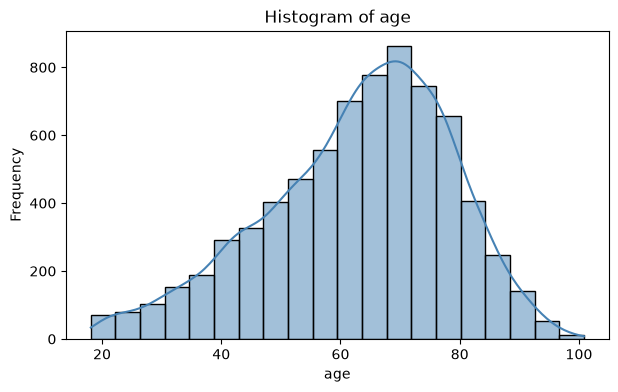

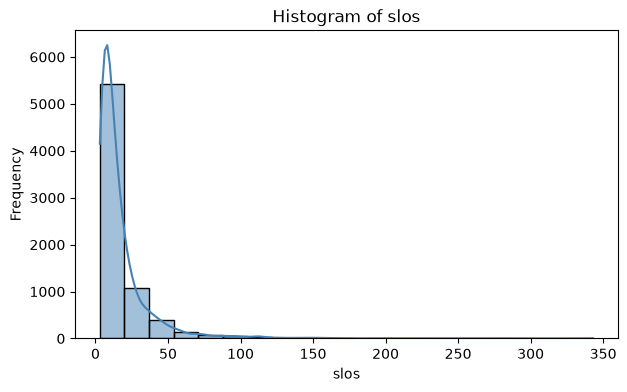

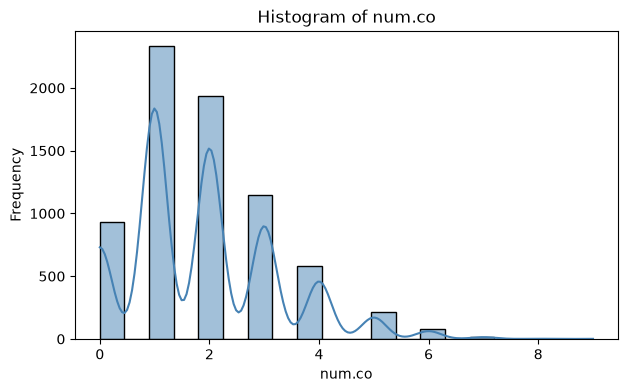

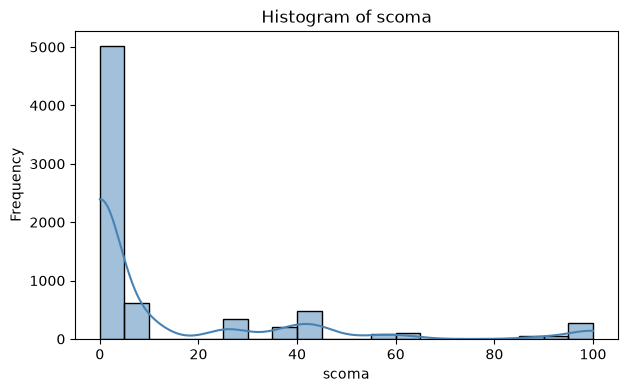

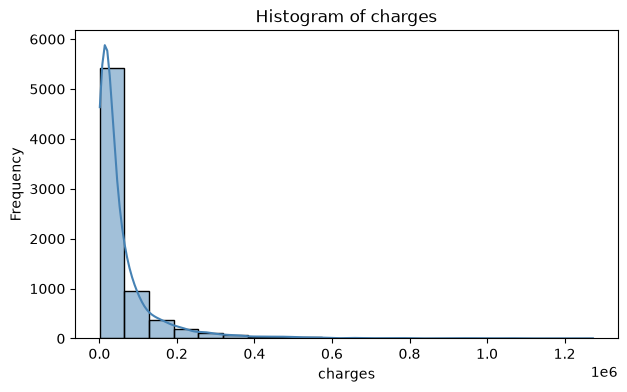

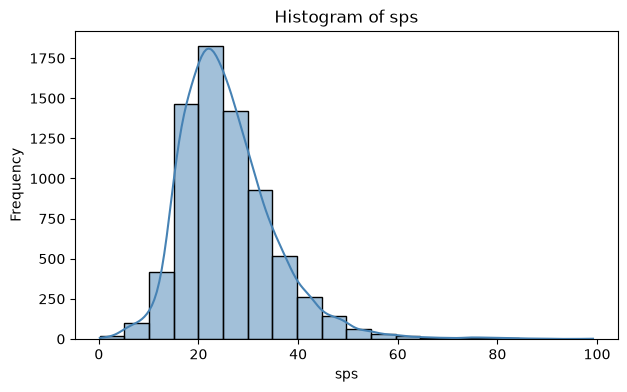

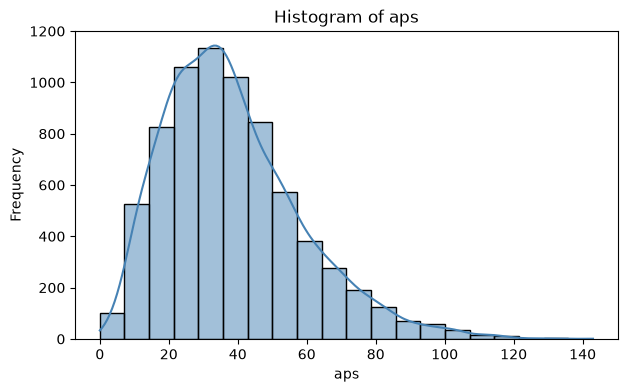

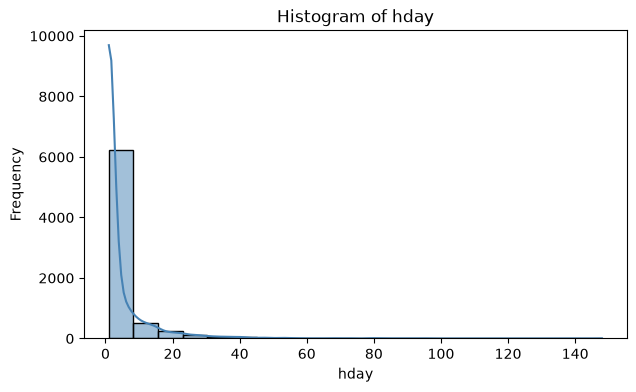

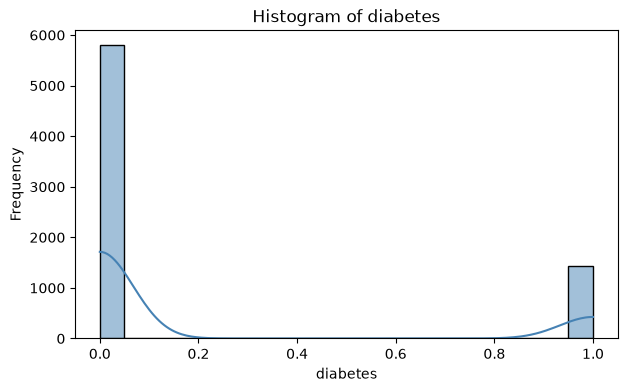

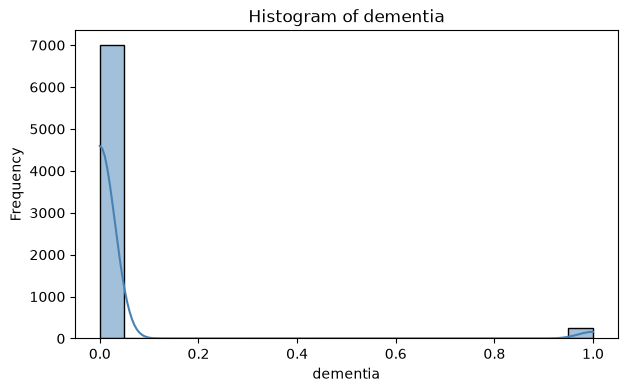

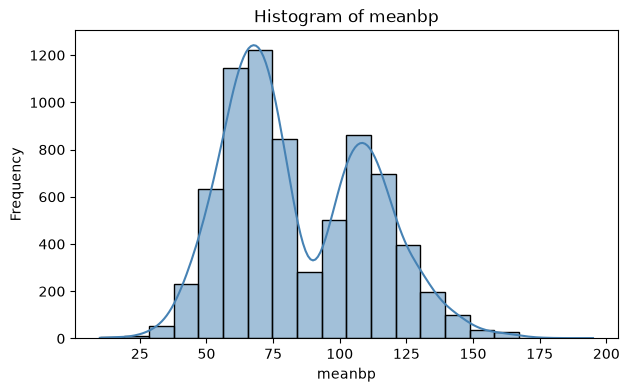

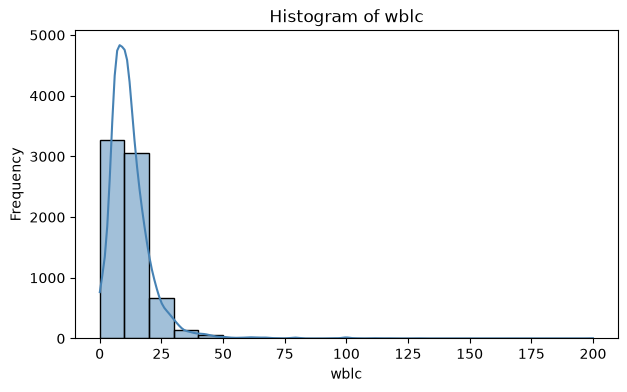

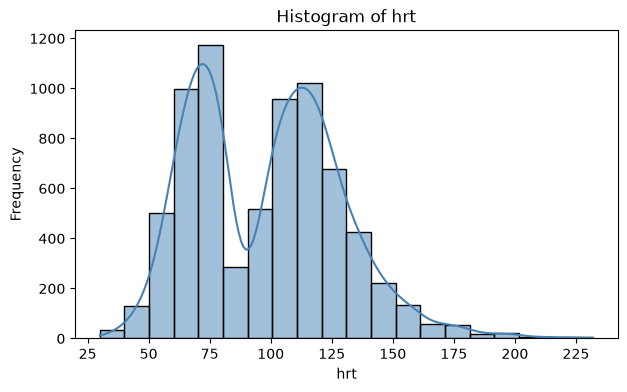

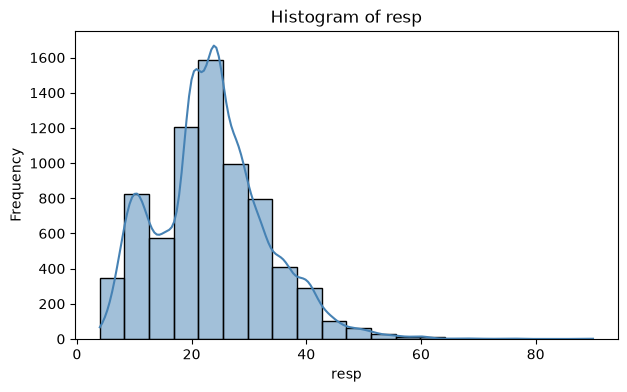

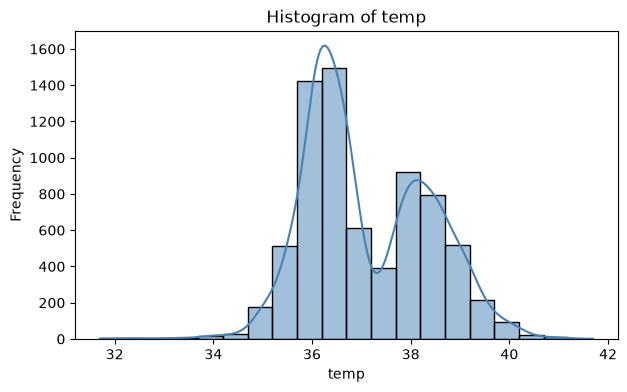

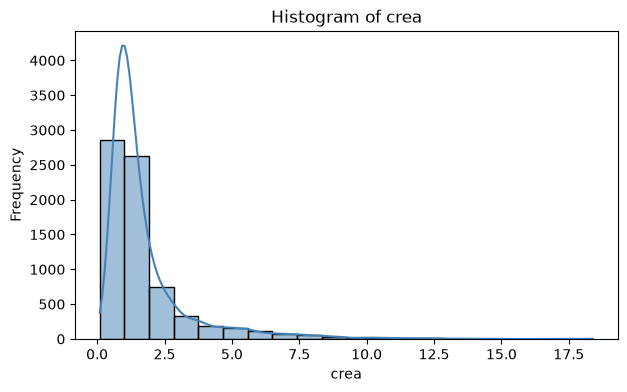

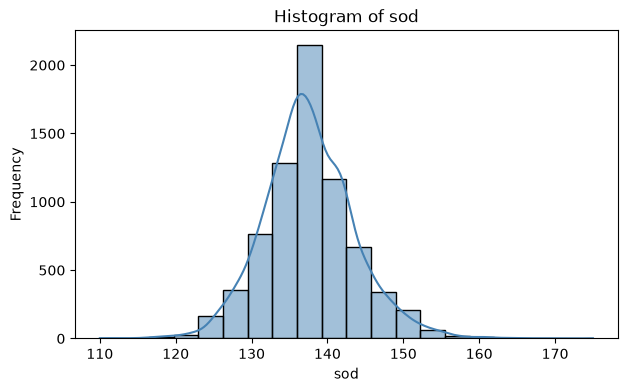

In [53]:
for col in numeric_cols_cleaned_version:#plotting with a loop to reduce repition and chunky/reduandand code.
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[col].dropna(), bins=20, kde=True, color="steelblue") #Kde set to true to visualise the trend with a line
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
